# Imports


In [1]:
# %load_ext autoreload
# %autoreload 2

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import xarray as xr

# Code

In [3]:
vprm_path = "/Users/rmaiwald/Levante/Paris/Input/Fluxes/VPRM/vprm_mean_2023.nc"
vprm_mean_2023 = xr.open_dataset(vprm_path)
xmin, xmax = vprm_mean_2023.x.min().item(), vprm_mean_2023.x.max().item()
ymin, ymax = vprm_mean_2023.y.min().item(), vprm_mean_2023.y.max().item()
LL_vprm = (xmin, ymin)
UR_vprm = (xmax, ymax)
print("VPRM dataset bounds:")
print("LL:", LL_vprm)
print("UR:", UR_vprm)

VPRM dataset bounds:
LL: (438505.0, 5402245.0)
UR: (469645.0, 5426855.0)


In [4]:
# From your email
LL = (447642.8640815755934455, 5404848.2594336671754718)
UR = (467642.8640815755934455, 5424848.2594336671754718)
CRS = "EPSG:32631"

In [5]:
# Define a domain bounds GeoDataFrame
xmin, xmax = LL[0], UR[0]
ymin, ymax = LL[1], UR[1]
domain_bounds = gpd.GeoDataFrame(
    geometry=[shapely.geometry.box(xmin, ymin, xmax, ymax)], crs=CRS
)

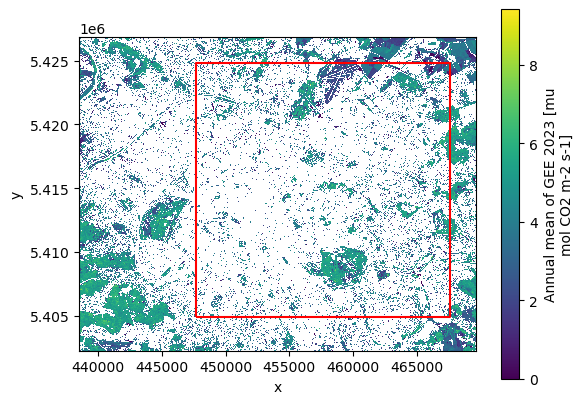

In [6]:
vprm_mean_2023.GEE.plot()
plt.gca().set_aspect("equal")
# Plot domain bounds
domain_bounds.boundary.plot(ax=plt.gca(), color="red")
plt.show()